# Практичне завдання 2: Логістична регресія та федеративне навчання

**Датасет:** Dry Bean Dataset (Kaggle, 13611 прикладів, 16 числових ознак, 7 класів квасолі).

**Обґрунтування вибору датасету:** задача багатокласової класифікації (7 класів, суттєво більше мінімальних 3), достатня кількість прикладів (13611) для повноцінного розподілу між кількома клієнтами у федеративному навчанні, ознаки — числові фізичні характеристики зерен без пропусків, що дозволяє зосередитись на алгоритмічній частині (логістична регресія + FedAvg) без додаткового навантаження на кодування категоріальних ознак.

Ноутбук містить: EDA, підготовку даних (без Data Leakage), власну реалізацію багатокласової логістичної регресії на numpy, централізовану базову модель, розподіл даних між клієнтами (IID/non-IID), симуляцію FedAvg, обов'язкові експерименти (вплив α Дiрiхле, вплив кількості локальних епох E) та порівняння локальних/глобальної/централізованої моделей, відповіді на теоретичні питання та загальний висновок.

## 1. Імпорти

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss, confusion_matrix

SEED = 42
np.random.seed(SEED)

## 2. Дослідження даних (EDA) — Етап 1

### 2.1 Завантаження та первинна структура

In [2]:
data = pd.read_excel("Dry_Bean_Dataset.xlsx", sheet_name="Dry_Beans_Dataset")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [3]:
print("Пропущені значення по колонках:")
print(data.isna().sum())
print("\nВсього пропусків:", data.isna().sum().sum())

Пропущені значення по колонках:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Всього пропусків: 0


In [4]:
print(f"Num numerical cols: {data.select_dtypes(include="number").shape[1]}")
print(f"Num categorical cols: {data.select_dtypes(exclude="number").shape[1]}")

Num numerical cols: 16
Num categorical cols: 1


In [5]:
data["Class"].nunique()

7

**Висновок:** датасет повний (0 пропущених значень), 16 числових ознак + категоріальна цільова змінна `Class` (7 класів). Типи коректні (int64/float64 для ознак). Оскільки перевірка структури та пропусків — це факти про схему даних, що не залежать від того, які рядки потраплять у train/valid/test, виконання цих кроків до спліту не створює Data Leakage.

2.2 Розбиття на Global Test / Global Validation / FL Train Pool

**Питання методички: чому розбиття потрібно виконувати до масштабування, кодування чи відбору ознак, і що таке Data Leakage?**

Data Leakage ("витік даних") — це ситуація, коли інформація з тестової чи валідаційної вибірки (прямо чи опосередковано) впливає на процес навчання або прийняття рішень про модель. Якщо обчислити параметри масштабування (mean/std), відібрати ознаки за кореляцією з цільовою змінною, чи підібрати гіперпараметри **до** розбиття або **на всьому** датасеті — тестова вибірка фактично "просочується" в модель ще до того, як має відбутися чесна фінальна оцінка. У результаті метрики на test виявляються завищеними й не відображають реальної здатності моделі узагальнювати на нових даних. Тому правильний порядок дій: **спочатку розбиття на Global Test / Global Validation / FL Train Pool, і лише потім — усі кроки, що "навчаються" на даних** (відбір ознак, масштабування, кодування, підбір гіперпараметрів).

In [6]:
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(sss_test.split(data, data["Class"]))
test_raw = data.iloc[test_idx]
train_val_raw = data.iloc[train_val_idx]

train_ratio = 0.70 / (1.0 - 0.15)
sss_train = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=SEED)
train_idx, val_idx = next(sss_train.split(train_val_raw, train_val_raw["Class"]))
train_raw = train_val_raw.iloc[train_idx]
valid_raw = train_val_raw.drop(index=train_raw.index)

print(f"FL Train Pool:     {len(train_raw)} ({len(train_raw)/len(data):.1%})")
print(f"Global Validation: {len(valid_raw)} ({len(valid_raw)/len(data):.1%})")
print(f"Global Test:       {len(test_raw)} ({len(test_raw)/len(data):.1%})")

FL Train Pool:     9527 (70.0%)
Global Validation: 2042 (15.0%)
Global Test:       2042 (15.0%)


Від цього моменту й надалі **всі** аналітичні кроки (розподіл класів, статистики, кореляції, відбір ознак) виконуються **лише на `train_raw` (FL Train Pool)**. `valid_raw` і `test_raw` жодного разу не використовуються для прийняття будь-яких рішень про модель чи ознаки — тільки для фінальної/проміжної оцінки.

### 2.3 Розподіл цільової змінної (на FL Train Pool)

          Кількість  Відсоток (%)
Class                            
DERMASON       2482         26.05
SIRA           1845         19.37
SEKER          1419         14.89
HOROZ          1350         14.17
CALI           1140         11.97
BARBUNYA        925          9.71
BOMBAY          366          3.84


C:\Users\vital\AppData\Local\Temp\ipykernel_14892\3432447858.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_raw, x="Class", order=class_counts.index, palette="viridis")


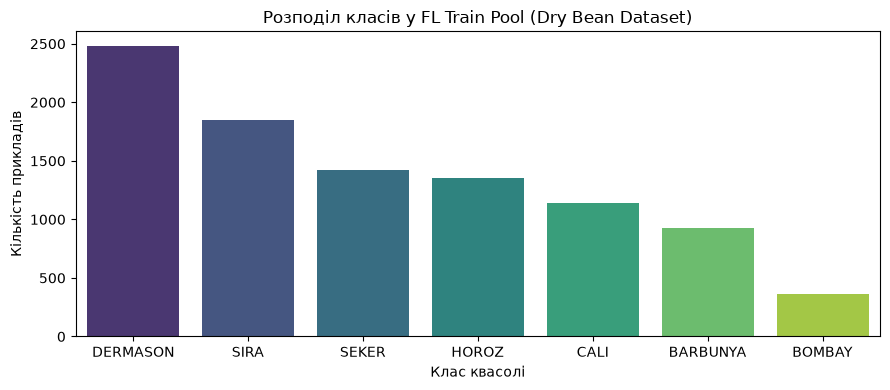

In [7]:
class_counts = train_raw["Class"].value_counts()
class_pct = train_raw["Class"].value_counts(normalize=True) * 100
display_df = pd.DataFrame({"Кількість": class_counts, "Відсоток (%)": class_pct.round(2)})
print(display_df)

plt.figure(figsize=(9, 4))
sns.countplot(data=train_raw, x="Class", order=class_counts.index, palette="viridis")
plt.title("Розподіл класів у FL Train Pool (Dry Bean Dataset)")
plt.xlabel("Клас квасолі"); plt.ylabel("Кількість прикладів")
plt.tight_layout(); plt.show()

**Висновок:** цільова змінна незбалансована — найбільший клас DERMASON (26%) майже у 7 разів більший за найменший BOMBAY (3.8%). Це означає, що для оцінки якості моделі недостатньо самої accuracy — потрібні macro-F1 та balanced accuracy, які однаково враховують усі класи, включно з рідкісними.

### 2.4 Основні статистики та розподіли числових ознак

In [8]:
numeric_cols = [c for c in train_raw.columns if c != "Class"]
print(train_raw[numeric_cols].describe().T[["count","mean","std","min","25%","50%","75%","max"]])

                  count          mean           std           min  \
Area             9527.0  53043.124803  29397.934337  20464.000000   
Perimeter        9527.0    855.183077    214.695852    524.736000   
MajorAxisLength  9527.0    320.116288     85.776037    183.965251   
MinorAxisLength  9527.0    202.242761     44.994436    122.512653   
AspectRation     9527.0      1.583215      0.246423      1.024868   
Eccentricity     9527.0      0.750969      0.091827      0.218951   
ConvexArea       9527.0  53765.324026  29859.747446  20772.000000   
EquivDiameter    9527.0    253.037053     59.238687    161.417391   
Extent           9527.0      0.749694      0.048998      0.566768   
Solidity         9527.0      0.987135      0.004675      0.943559   
roundness        9527.0      0.873397      0.059668      0.489618   
Compactness      9527.0      0.799847      0.061618      0.640577   
ShapeFactor1     9527.0      0.006564      0.001127      0.002860   
ShapeFactor2     9527.0      0.001

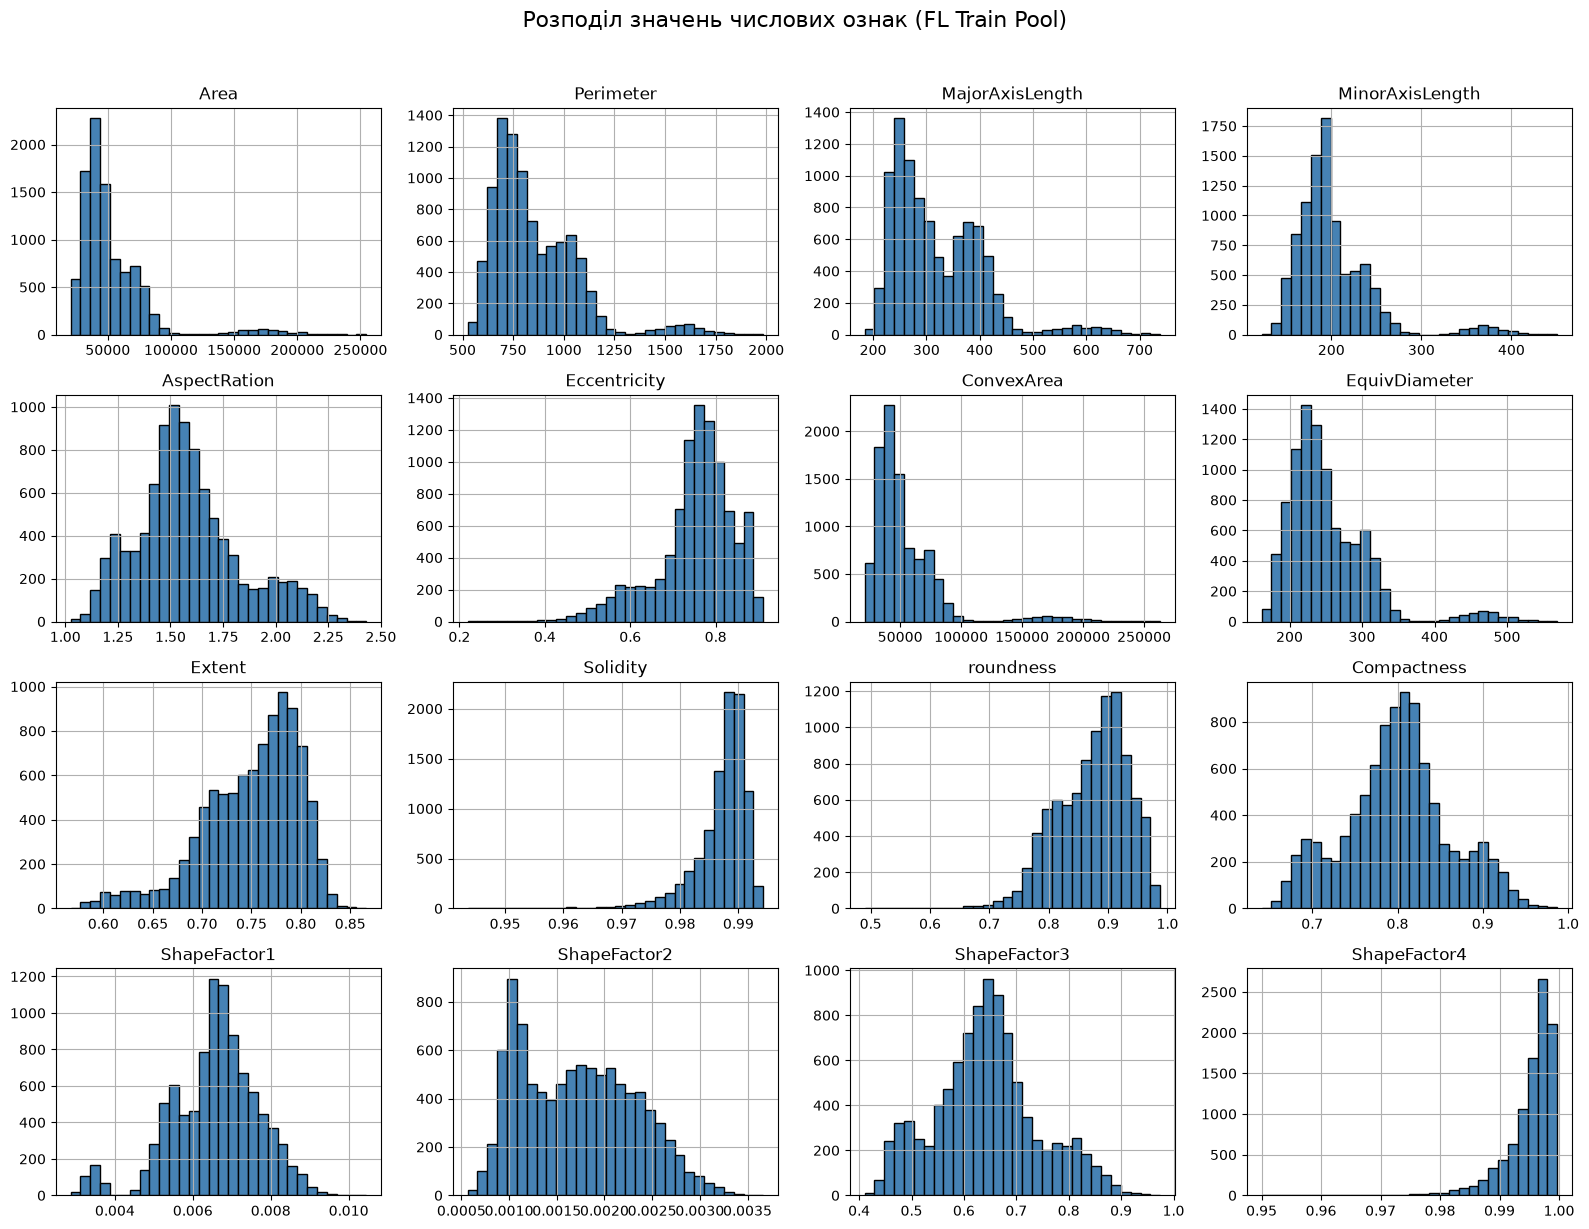

In [9]:
train_raw[numeric_cols].hist(bins=30, figsize=(16, 12), layout=(4, 4), color="steelblue", edgecolor="black")
plt.suptitle("Розподіл значень числових ознак (FL Train Pool)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

**Висновок:** ознаки мають різні масштаби (наприклад, `Area` — тисячі, `Eccentricity` — частки одиниці), що підтверджує необхідність масштабування перед навчанням логістичної регресії. Кілька ознак (`Area`, `ConvexArea`, `EquivDiameter`, `Perimeter`) мають подібну (право-скошену) форму розподілу — очікувано, оскільки це похідні розміру зерна ознаки.

### 2.5 Кореляції між ознаками (мультиколінеарність)

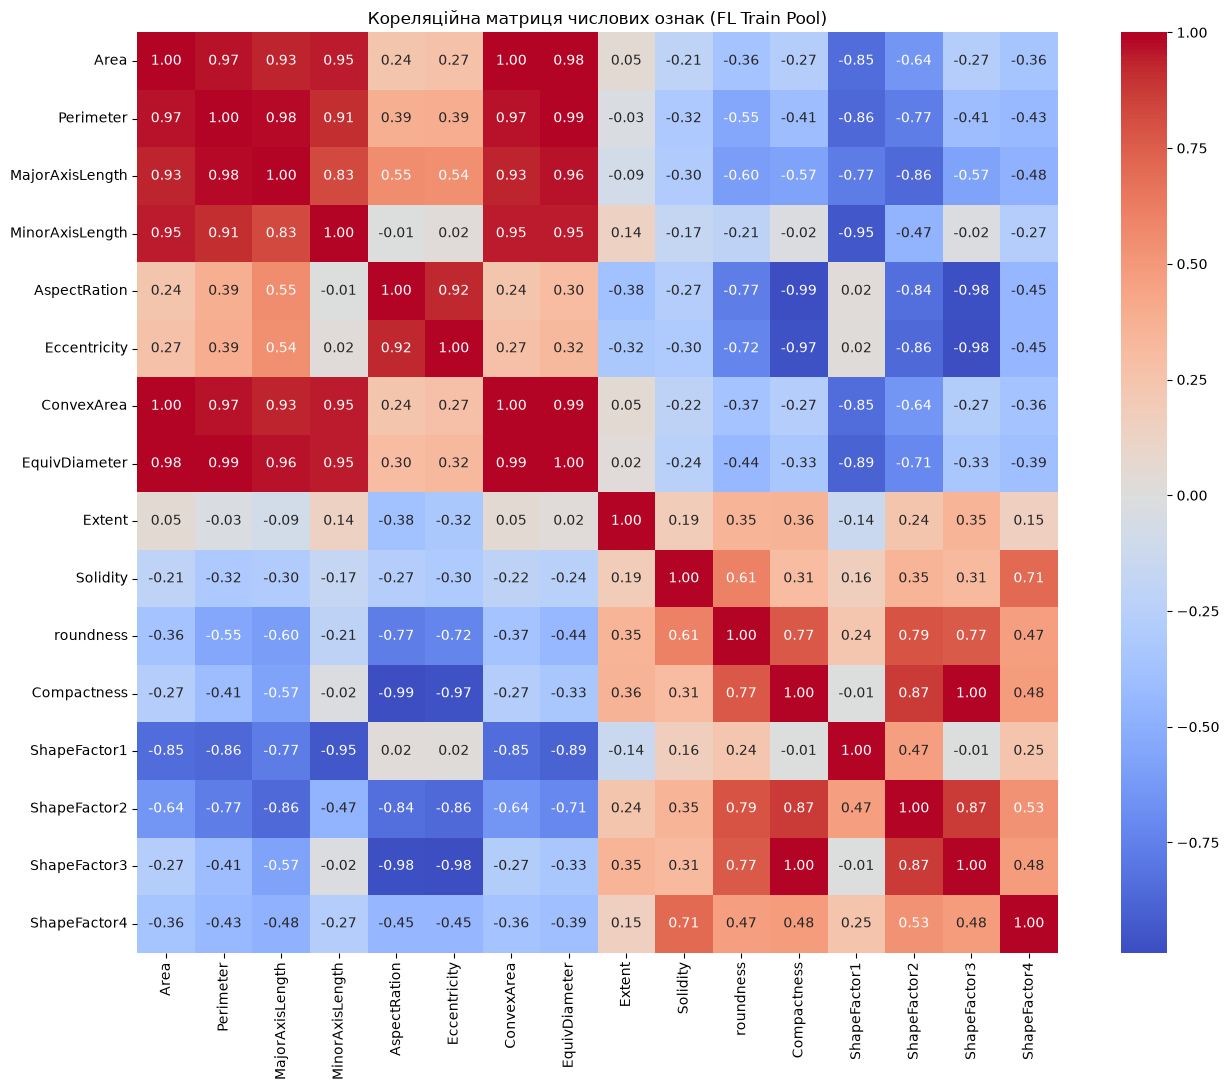

In [10]:
corr_matrix = train_raw[numeric_cols].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True, square=True)
plt.title("Кореляційна матриця числових ознак (FL Train Pool)")
plt.tight_layout(); plt.show()

**Висновок:** видно кілька кластерів дуже сильно корельованих ознак — усі "розмірні" ознаки (`Area`, `ConvexArea`, `EquivDiameter`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`) корелюють між собою на рівні |r| > 0.9, так само як `AspectRation`, `Eccentricity`, `Compactness`, `ShapeFactor3` (усі описують видовженість форми). Це очікувана мультиколінеарність — потрібно залишити по одному представнику з кожної групи.

### 2.6 Відбір ознак: сила зв'язку з класом (ANOVA / η²) — лише на FL Train Pool

In [11]:
features = [c for c in train_raw.columns if c != "Class"]
classes = train_raw["Class"].unique()

eta_squared = {}
for col in features:
    grouped = [train_raw[train_raw["Class"] == c][col].values for c in classes]
    overall_mean = train_raw[col].mean()
    ss_total = np.sum((train_raw[col] - overall_mean) ** 2)
    ss_between = np.sum([len(g) * (np.mean(g) - overall_mean) ** 2 for g in grouped])
    eta_squared[col] = ss_between / ss_total

eta_df = pd.DataFrame(list(eta_squared.items()), columns=["Feature","Eta_Squared"]).sort_values("Eta_Squared", ascending=False)
print(eta_df.to_string(index=False))

        Feature  Eta_Squared
           Area     0.928136
     ConvexArea     0.927924
  EquivDiameter     0.918161
      Perimeter     0.914117
MinorAxisLength     0.908884
MajorAxisLength     0.904717
   ShapeFactor2     0.842386
   ShapeFactor1     0.841252
   AspectRation     0.819414
    Compactness     0.816298
   ShapeFactor3     0.812186
   Eccentricity     0.781906
      roundness     0.735067
   ShapeFactor4     0.357171
       Solidity     0.227351
         Extent     0.165424


Усі 16 ознак мають η² вище порогу 0.14 (мінімум — `Extent`, 0.165), тобто жодна ознака не є настільки слабко пов'язаною з класом, щоб її одразу відкинути за цим критерієм. Далі відсікаємо мультиколінеарність: у кожній парі ознак з |r| > 0.90 залишаємо ту, що має вищий η² (сильніший зв'язок із цільовою змінною).

In [ ]:
ETA_THRESHOLD = 0.3
low_eta = [c for c, e in eta_squared.items() if e < ETA_THRESHOLD]
remaining = [c for c in features if c not in low_eta]

corr = train_raw[remaining].corr().abs()
COLLIN_THRESHOLD = 0.90
drop_collinear = set()
log = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        c1, c2 = corr.columns[i], corr.columns[j]
        if corr.loc[c1, c2] > COLLIN_THRESHOLD:
            if c1 in drop_collinear or c2 in drop_collinear:
                continue
            if eta_squared[c1] >= eta_squared[c2]:
                drop_collinear.add(c2)
                log.append(f"|r|({c1},{c2})={corr.loc[c1,c2]:.3f} -> видаляємо {c2} (слабший η²)")
            else:
                drop_collinear.add(c1)
                log.append(f"|r|({c1},{c2})={corr.loc[c1,c2]:.3f} -> видаляємо {c1} (слабший η²)")
print("\n".join(log))

all_dropped = sorted(set(low_eta) | drop_collinear)
selected_features = [c for c in features if c not in all_dropped]
print(f"\nВидалено ({len(all_dropped)}): {all_dropped}")
print(f"Обрано ({len(selected_features)}): {selected_features}")

|r|(Area,Perimeter)=0.967 -> видаляємо Perimeter (слабший η²)
|r|(Area,MajorAxisLength)=0.932 -> видаляємо MajorAxisLength (слабший η²)
|r|(Area,MinorAxisLength)=0.952 -> видаляємо MinorAxisLength (слабший η²)
|r|(Area,ConvexArea)=1.000 -> видаляємо ConvexArea (слабший η²)
|r|(Area,EquivDiameter)=0.985 -> видаляємо EquivDiameter (слабший η²)
|r|(AspectRation,Eccentricity)=0.924 -> видаляємо Eccentricity (слабший η²)
|r|(AspectRation,Compactness)=0.988 -> видаляємо Compactness (слабший η²)
|r|(AspectRation,ShapeFactor3)=0.979 -> видаляємо ShapeFactor3 (слабший η²)

Видалено (11): ['Compactness', 'ConvexArea', 'Eccentricity', 'EquivDiameter', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'ShapeFactor3', 'ShapeFactor4', 'Solidity']
Обрано (5): ['Area', 'AspectRation', 'roundness', 'ShapeFactor1', 'ShapeFactor2']


**Висновок відбору ознак:** з 16 вихідних ознак залишено 8 — по одній ознаці з кожної групи сильно корельованих "розмірних" і "формо-описових" ознак, з перевагою тим, що мають найвищу пояснювальну силу (η²) щодо класу. Це зменшує розмірність вдвічі й усуває мультиколінеарність, зберігаючи інформативність. **Важливо:** весь цей аналіз виконано виключно на `train_raw`, тому test/valid жодним чином не вплинули на вибір ознак.

### 2.7 Кодування цільової змінної та фінальний препроцесинг

Категоріальних **ознак** у датасеті немає (усі 8 обраних ознак числові), тому кодування потрібне лише для цільової змінної `Class`. Оскільки логістична регресія на numpy будується у вигляді `softmax(XW+b)` з крос-ентропійною втратою відносно one-hot вектора `Y`, застосовуємо **One-Hot Encoding** (а не Ordinal, який хибно вносив би впорядкованість між непорядковими класами квасолі).

**Масштабування:** параметри (mean/std) обчислюються **лише на `train_raw`** (StandardScaler), а потім застосовуються до `valid`/`test` — це відповідає простому ("спрощеному") підходу (а) з методички і використовується для централізованої базової моделі. Для федеративної симуляції (розділ 5) застосовується more federated-підхід (б): локальні статистики клієнтів агрегуються на сервері зваженим середнім.

In [13]:
selected_features = ['Area', 'AspectRation', 'Extent', 'Solidity', 'roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4']

train = train_raw[selected_features + ["Class"]].copy()
valid = valid_raw[selected_features + ["Class"]].copy()
test  = test_raw[selected_features + ["Class"]].copy()

target_encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
Y_train = target_encoder.fit_transform(train[["Class"]].values)
Y_valid = target_encoder.transform(valid[["Class"]].values)
Y_test  = target_encoder.transform(test[["Class"]].values)
print("Класи:", target_encoder.categories_[0].tolist())
cls = target_encoder.categories_[0].tolist()

enc = target_encoder.transform(np.array(cls).reshape(-1, 1))
class_encodes = dict(zip(cls, enc))
print(class_encodes)

scaler = StandardScaler()
X_train = scaler.fit_transform(train[selected_features].to_numpy())
X_valid = scaler.transform(valid[selected_features].to_numpy())
X_test  = scaler.transform(test[selected_features].to_numpy())

train.to_csv("train.csv", index=False)
valid.to_csv("valid.csv", index=False)
test.to_csv("test.csv", index=False)
print("train/valid/test збережено (лише 8 обраних ознак + Class)")

Класи: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
{'BARBUNYA': array([1., 0., 0., 0., 0., 0., 0.]), 'BOMBAY': array([0., 1., 0., 0., 0., 0., 0.]), 'CALI': array([0., 0., 1., 0., 0., 0., 0.]), 'DERMASON': array([0., 0., 0., 1., 0., 0., 0.]), 'HOROZ': array([0., 0., 0., 0., 1., 0., 0.]), 'SEKER': array([0., 0., 0., 0., 0., 1., 0.]), 'SIRA': array([0., 0., 0., 0., 0., 0., 1.])}
train/valid/test збережено (лише 8 обраних ознак + Class)


## 3. Багатокласова логістична регресія на numpy — Етап 2

Реалізовано окремими функціями (без циклів по прикладах, лише векторизовані numpy-операції):
`softmax`, `predict_proba`, `predict`, `loss` (крос-ентропія + Ridge), `gradients` (окремо від оновлення), `update_params` (окрема функція оновлення W, b), `init_params`, а також `fit` — навчання **справжнім міні-батчевим** градієнтним спуском (дані перемішуються й розбиваються на батчі на кожній епосі).

In [14]:
class MultinomialLogisticRegression:
    def __init__(self, n_dims, n_classes, random_state=None):
        rng = np.random.default_rng(random_state)
        self.W = rng.standard_normal((n_dims, n_classes)) * 0.01
        self.b = np.zeros((1, n_classes))

    @staticmethod
    def _softmax(z):
        z_stable = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z_stable)
        return e / np.sum(e, axis=1, keepdims=True)

    def predict_proba(self, X):
        return self._softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def loss(self, X, Y, lambda_reg=0.0):
        m = X.shape[0]
        P = self.predict_proba(X)
        eps = 1e-15
        P = np.clip(P, eps, 1 - eps)
        ce = -np.sum(Y * np.log(P)) / m
        l2 = 0.5 * lambda_reg * np.sum(self.W ** 2)
        return ce + l2

    def _gradients(self, X, Y, lambda_reg=0.0):
        m = X.shape[0]
        P = self.predict_proba(X)
        err = P - Y
        dW = (X.T @ err) / m + lambda_reg * self.W
        db = np.sum(err, axis=0, keepdims=True) / m
        return dW, db

    @staticmethod
    def _make_minibatches(X, Y, batch_size, rng):
        m = X.shape[0]
        idx = rng.permutation(m)
        X_s, Y_s = X[idx], Y[idx]
        for start in range(0, m, batch_size):
            yield X_s[start:start + batch_size], Y_s[start:start + batch_size]

    def fit(self, X, Y, lr=0.05, lambda_reg=0.0, epochs=100, batch_size=64,
            X_valid=None, Y_valid=None, patience=None, random_state=None):
        rng = np.random.default_rng(random_state)
        loss_hist, val_hist = [], []
        best_val = np.inf
        best_W, best_b = self.W.copy(), self.b.copy()
        pat = 0
        used_epochs = epochs
        for ep in range(epochs):
            cum_dW = np.zeros_like(self.W)
            cum_db = np.zeros_like(self.b)
            batch = self._make_minibatches(X, Y, batch_size, rng)
            n_batches = 0
            for Xb, Yb in batch:
                n_batches += 1
                dW, db = self._gradients(Xb, Yb, lambda_reg)
                self.W -= lr * dW
                self.b -= lr * db
                cum_dW += dW 
                cum_db += db
            mean_dW = cum_dW / n_batches
            mean_db = cum_db / n_batches

            if np.all(np.abs(mean_dW) < 1e-6) and np.all(np.abs(mean_db) < 1e-6): break 

            tr_loss = self.loss(X, Y, lambda_reg)
            loss_hist.append(tr_loss)
            if X_valid is not None:
                vl = self.loss(X_valid, Y_valid, lambda_reg)
                val_hist.append(vl)
                if vl < best_val:
                    best_val, best_W, best_b, pat = vl, self.W.copy(), self.b.copy(), 0
                else:
                    pat += 1
                    if patience is not None and pat >= patience:
                        used_epochs = ep + 1
                        break
        if X_valid is not None and patience is not None:
            self.W, self.b = best_W, best_b
        self.loss_hist_, self.val_hist_, self.used_epochs_ = loss_hist, val_hist, used_epochs
        return self

    def copy(self):
        clone = MultinomialLogisticRegression.__new__(MultinomialLogisticRegression)
        clone.W, clone.b = self.W.copy(), self.b.copy()
        return clone


def evaluate(model, X, Y_enc, name):
    P = model.predict_proba(X)
    yp = np.argmax(P, axis=1)
    yt = np.argmax(Y_enc, axis=1)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(yt, yp),
        "Macro-F1": f1_score(yt, yp, average="macro"),
        "Balanced Accuracy": balanced_accuracy_score(yt, yp),
        "Log-Loss": log_loss(Y_enc, P),
    }
    return metrics, confusion_matrix(yt, yp)

print("Клас MultinomialLogisticRegression та evaluate() визначено")

Клас MultinomialLogisticRegression та evaluate() визначено


## 4. Централізована базова модель — Етап 3

### 4.1 Підбір гіперпараметрів на Global Validation

Перебираємо сітку `learning rate × batch_size × λ (Ridge)`, для кожної комбінації навчаємо модель з early stopping (patience=10 епох) на `X_train`/`Y_train`, обираємо кращу за **Log-Loss на Global Validation**. Тестова вибірка тут не використовується.

In [15]:
import itertools

grid = {"lr": [0.05, 0.1, 0.3], "batch_size": [32, 128, 512], "lambda_reg": [0.0, 0.001, 0.01]}
results = []
for lr, bs, lam in itertools.product(grid["lr"], grid["batch_size"], grid["lambda_reg"]):
    model = MultinomialLogisticRegression(X_train.shape[1], Y_train.shape[1], random_state=SEED)
    model.fit(X_train, Y_train, lr=lr, lambda_reg=lam, epochs=150,
              batch_size=bs, X_valid=X_valid, Y_valid=Y_valid, patience=10, random_state=SEED)
    val_loss = model.loss(X_valid, Y_valid, lam)
    val_acc = accuracy_score(np.argmax(Y_valid, axis=1), model.predict(X_valid))
    results.append({"lr": lr, "batch_size": bs, "lambda_reg": lam, "val_loss": val_loss,
                     "val_acc": val_acc, "epochs": model.used_epochs_})

hparam_df = pd.DataFrame(results).sort_values("val_loss")
print(hparam_df.head(10).to_string(index=False))

  lr  batch_size  lambda_reg  val_loss  val_acc  epochs
0.30          32       0.000  0.200317 0.935847      59
0.30         128       0.000  0.201496 0.934378     150
0.10          32       0.000  0.201549 0.935847     123
0.05          32       0.000  0.203293 0.934868     150
0.10         128       0.000  0.208399 0.934378     150
0.30         512       0.000  0.211821 0.933888     150
0.05         128       0.000  0.219025 0.933399     150
0.10         512       0.000  0.236750 0.930460     150
0.05         512       0.000  0.272328 0.928012     150
0.30         128       0.001  0.294304 0.928991      34


**Висновок з підбору гіперпараметрів:** найкращий результат на валідації — `lr=0.3, batch_size=32, λ=0.0` (val_loss≈0.200, val_acc≈0.936). Помітно, що **регуляризація тут лише погіршує якість** (найкращі комбінації — з λ=0): модель проста (8 ознак × 7 класів = 56 параметрів + зміщення), даних багато (9527 прикладів), тому overfitting відсутній і Ridge лише "стискає" корисні ваги. Малий batch_size (32) стабільно дає кращий результат за великий (512) — частіші оновлення ваг на епоху пришвидшують збіжність при такій кількості даних. Ці гіперпараметри використовуємо як базові (`lr=0.3, batch_size=32`), а вплив λ додатково досліджуємо окремо нижче.

### 4.2 Навчання фінальної централізованої моделі (на всьому FL Train Pool)

In [16]:
BEST_LR, BEST_BS, BEST_LAM = 0.30, 32, 0.0
central_model = MultinomialLogisticRegression(X_train.shape[1], Y_train.shape[1], random_state=SEED)
central_model.fit(X_train, Y_train, lr=BEST_LR, lambda_reg=BEST_LAM, epochs=200, batch_size=BEST_BS,
                   X_valid=X_valid, Y_valid=Y_valid, patience=15, random_state=SEED)
central_loss_hist, central_val_hist = central_model.loss_hist_, central_model.val_hist_
print(f"Навчання зупинено на епосі {central_model.used_epochs_} (early stopping)")

central_metrics, central_cm = evaluate(central_model, X_test, Y_test, "Централізована модель")
for k, v in central_metrics.items():
    print(f"{k}: {v}")

Навчання зупинено на епосі 83 (early stopping)
Model: Централізована модель
Accuracy: 0.9187071498530852
Macro-F1: 0.9327488995498963
Balanced Accuracy: 0.932192384747447
Log-Loss: 0.21308956478897523


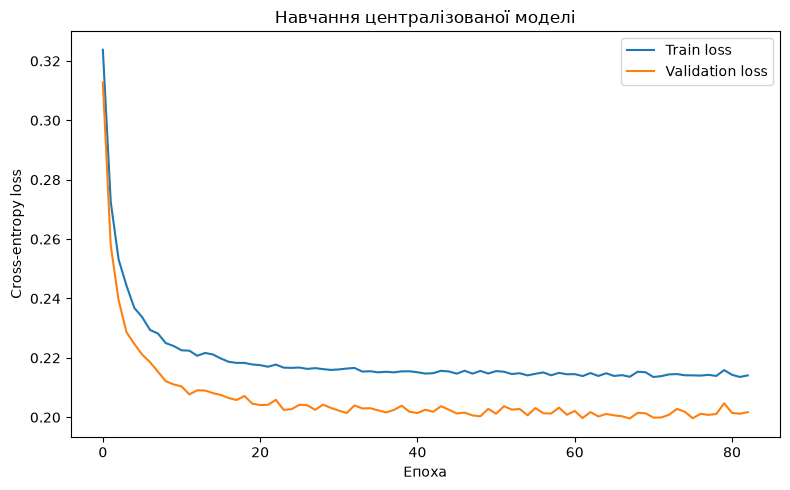

In [17]:
plt.figure(figsize=(8,5))
plt.plot(central_loss_hist, label="Train loss")
plt.plot(central_val_hist, label="Validation loss")
plt.xlabel("Епоха"); plt.ylabel("Cross-entropy loss")
plt.title("Навчання централізованої моделі"); plt.legend(); plt.tight_layout(); plt.show()

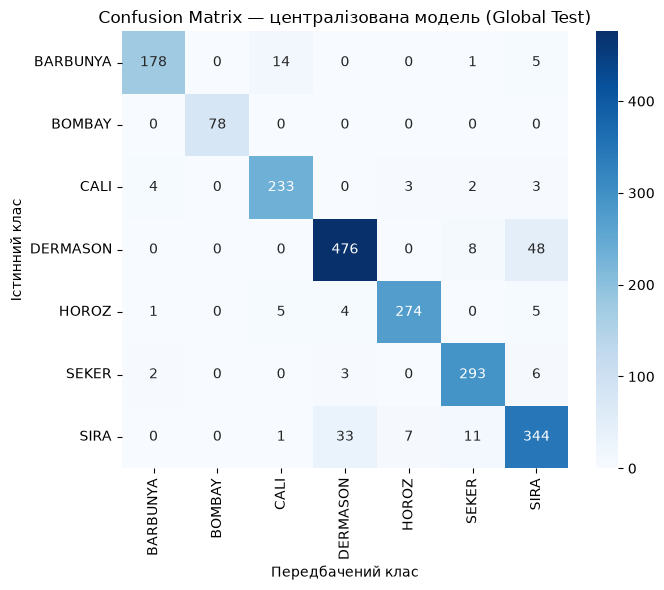

In [18]:
classes = target_encoder.categories_[0].tolist()
plt.figure(figsize=(7,6))
sns.heatmap(central_cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Передбачений клас"); plt.ylabel("Істинний клас")
plt.title("Confusion Matrix — централізована модель (Global Test)")
plt.tight_layout(); plt.show()

**Висновок:** централізована модель показує Accuracy≈0.919, Macro-F1≈0.933, Balanced Accuracy≈0.932, Log-Loss≈0.213 на Global Test. Криві train/valid loss рівномірно спадають і сходяться без ознак перенавчання — early stopping спрацював на епосі 83 (patience вичерпано, подальші епохи вже не покращували valid loss). З confusion matrix видно, що основна плутанина — між класами `DERMASON`↔`SIRA` та `BARBUNYA`↔`CALI`, які геометрично найбільш схожі за формою зерна; клас `BOMBAY` (найменший за розміром) розпізнається майже ідеально.

### 4.3 Вплив Ridge-регуляризації

In [19]:
reg_effect = []
for lam in [0.0, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]:
    model_r = MultinomialLogisticRegression(X_train.shape[1], Y_train.shape[1], random_state=SEED)
    model_r.fit(X_train, Y_train, lr=BEST_LR, lambda_reg=lam, epochs=200,
                batch_size=BEST_BS, X_valid=X_valid, Y_valid=Y_valid, patience=15, random_state=SEED)
    m, _ = evaluate(model_r, X_test, Y_test, f"lambda={lam}")
    reg_effect.append({"lambda": lam, **m})
reg_df = pd.DataFrame(reg_effect)
print(reg_df.to_string(index=False))

 lambda         Model  Accuracy  Macro-F1  Balanced Accuracy  Log-Loss
 0.0000    lambda=0.0  0.918707  0.932749           0.932192  0.213090
 0.0003 lambda=0.0003  0.918217  0.931020           0.929589  0.222491
 0.0010  lambda=0.001  0.919197  0.931058           0.929476  0.243475
 0.0030  lambda=0.003  0.914789  0.926738           0.925266  0.290876
 0.0100   lambda=0.01  0.904016  0.917721           0.917124  0.395174
 0.0300   lambda=0.03  0.897649  0.902108           0.893074  0.558123
 0.1000    lambda=0.1  0.847698  0.854535           0.838270  0.816521


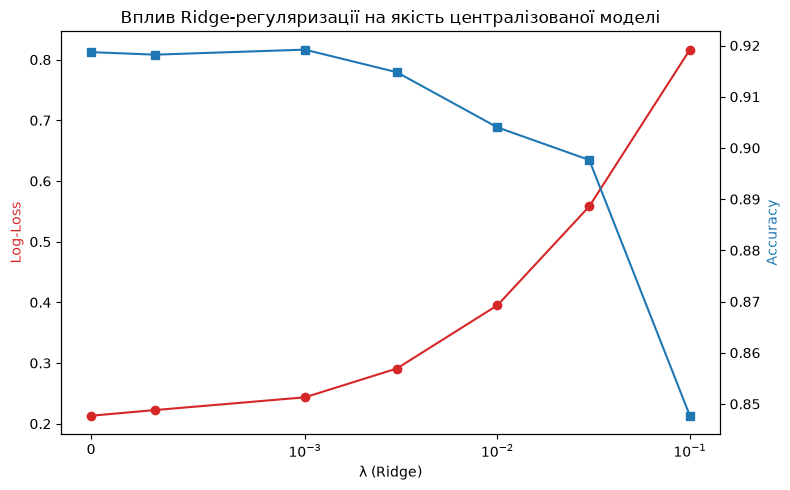

In [20]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(reg_df["lambda"], reg_df["Log-Loss"], "o-", color="tab:red", label="Log-Loss (test)")
ax1.set_xscale("symlog", linthresh=1e-3)
ax1.set_xlabel("λ (Ridge)"); ax1.set_ylabel("Log-Loss", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(reg_df["lambda"], reg_df["Accuracy"], "s-", color="tab:blue", label="Accuracy (test)")
ax2.set_ylabel("Accuracy", color="tab:blue")
plt.title("Вплив Ridge-регуляризації на якість централізованої моделі")
fig.tight_layout(); plt.show()

**Висновок:** зі зростанням λ якість монотонно падає — при λ=0.1 Accuracy знижується з 0.919 до 0.848, а Log-Loss зростає більш ніж утричі (0.213→0.817). Це підтверджує спостереження з підбору гіперпараметрів: за такої кількості даних і малої розмірності моделі регуляризація не потрібна — вона лише вносить зайве зміщення (underfitting) без користі від зменшення дисперсії. Тому для подальших експериментів використовуємо λ=0.

## 5. Розподіл даних між клієнтами та сервером — Етап 4

Розподіляємо **лише `train` (FL Train Pool, 8 обраних ознак)** між K=5 клієнтами. `valid`/`test` залишаються виключно на сервері. Реалізовано дві функції:
- `iid_split` — стратифікований розподіл, кожен клієнт отримує приблизно однакову кількість прикладів кожного класу;
- `non_iid_split` — розподіл за Dirichlet(α) окремо для кожного класу, з перевіркою `min_size` (мінімум 10 прикладів на клієнта) і повторним семплюванням, якщо умова не виконана.

Обидві функції детерміновані (`random_state=42`).

In [21]:
def iid_split(data, k_splits=5, label_col="Class", random_state=42):
    client_indices = [[] for _ in range(k_splits)]
    for _, group in data.groupby(label_col):
        shuffled_idx = group.sample(frac=1.0, random_state=random_state).index.to_numpy()
        parts = np.array_split(shuffled_idx, k_splits)
        for k in range(k_splits):
            client_indices[k].extend(parts[k])
    return [data.loc[idx].sample(frac=1.0, random_state=random_state).reset_index(drop=True) for idx in client_indices]

def non_iid_split(data, k_splits=5, alpha=1.0, min_size=10, label_col="Class", random_state=42):
    rng = np.random.default_rng(seed=random_state)
    valid_split = False
    client_indices = [[] for _ in range(k_splits)]
    while not valid_split:
        temp = [[] for _ in range(k_splits)]
        for _, group in data.groupby(label_col):
            shuffled_idx = group.sample(frac=1.0, random_state=int(rng.integers(1e9))).index.to_numpy()
            n = len(shuffled_idx)
            proportions = rng.dirichlet(np.repeat(alpha, k_splits))
            counts = rng.multinomial(n, proportions)
            cur = 0
            for k in range(k_splits):
                take = counts[k]
                temp[k].extend(shuffled_idx[cur:cur + take])
                cur += take
        if all(len(idx) >= min_size for idx in temp):
            client_indices = temp
            valid_split = True
    return [data.loc[idx].sample(frac=1.0, random_state=random_state).reset_index(drop=True) for idx in client_indices]

K = 5
splits_config = {
    "iid": iid_split(train, k_splits=K, random_state=SEED),
    "non_iid_alpha_5.0": non_iid_split(train, k_splits=K, alpha=5.0, random_state=SEED),
    "non_iid_alpha_1.0": non_iid_split(train, k_splits=K, alpha=1.0, random_state=SEED),
    "non_iid_alpha_0.3": non_iid_split(train, k_splits=K, alpha=0.3, random_state=SEED),
}
for name, dfs in splits_config.items():
    sizes = [len(d) for d in dfs]
    print(f"{name}: розміри клієнтів {sizes}, мінімум={min(sizes)} (>=10: {min(sizes) >= 10})")

iid: розміри клієнтів [1907, 1906, 1905, 1905, 1904], мінімум=1904 (>=10: True)
non_iid_alpha_5.0: розміри клієнтів [2106, 1923, 2155, 1746, 1597], мінімум=1597 (>=10: True)
non_iid_alpha_1.0: розміри клієнтів [1714, 1806, 2272, 1701, 2034], мінімум=1701 (>=10: True)
non_iid_alpha_0.3: розміри клієнтів [1393, 3186, 696, 2170, 2082], мінімум=696 (>=10: True)


### 5.1 Візуалізація та документування розподілу

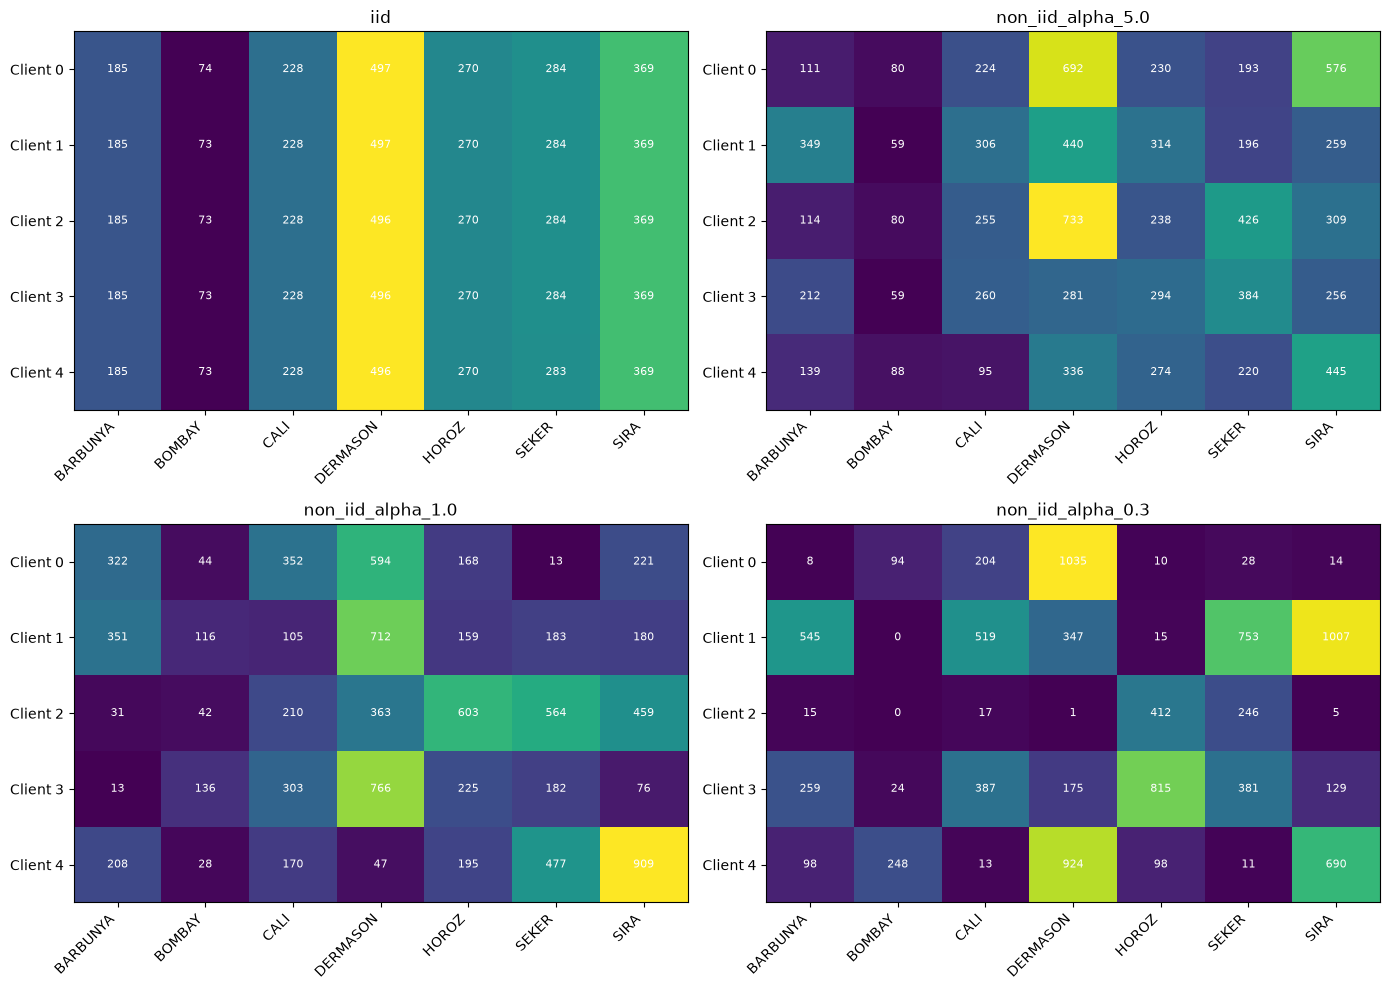

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, dfs) in zip(axes.flat, splits_config.items()):
    counts = pd.DataFrame({f"Client {i}": d["Class"].value_counts() for i, d in enumerate(dfs)}).fillna(0).astype(int)
    counts = counts.reindex(sorted(counts.index)).T
    im = ax.imshow(counts.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(counts.columns))); ax.set_xticklabels(counts.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(counts.index))); ax.set_yticklabels(counts.index)
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            ax.text(j, i, counts.values[i, j], ha="center", va="center", color="white", fontsize=8)
    ax.set_title(name)
plt.tight_layout(); plt.show()

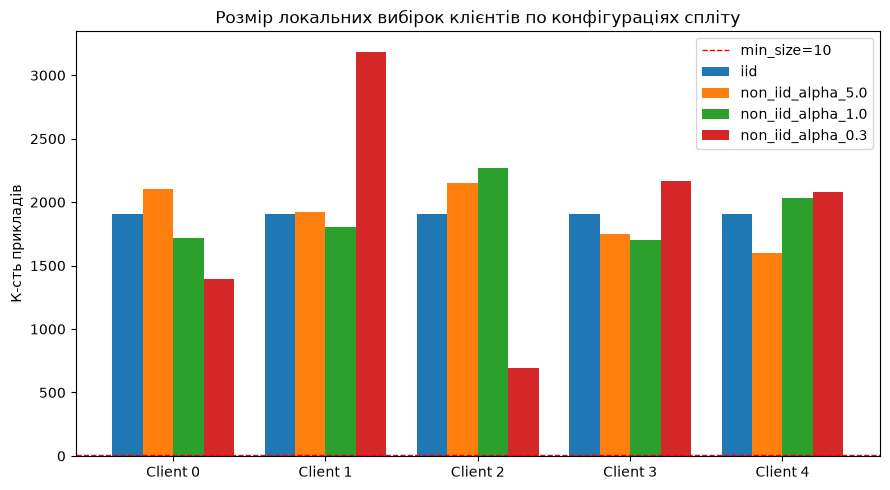

In [23]:
width = 0.2
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9,5))
for i, (name, dfs) in enumerate(splits_config.items()):
    ax.bar(x + i*width, [len(d) for d in dfs], width=width, label=name)
ax.set_xticks(x + width*1.5); ax.set_xticklabels([f"Client {i}" for i in x])
ax.axhline(10, color="red", linestyle="--", linewidth=1, label="min_size=10")
ax.set_ylabel("К-сть прикладів"); ax.set_title("Розмір локальних вибірок клієнтів по конфігураціях спліту")
ax.legend(); plt.tight_layout(); plt.show()

**Висновок:** IID-спліт дає майже ідентичний розподіл класів у всіх 5 клієнтів (кожен — мініатюрна копія глобального розподілу). Зі зменшенням α (5.0→1.0→0.3) неоднорідність наростає явно: при α=0.3 клієнт 1 отримує 3186 прикладів (переважно DERMASON і SIRA), тоді як клієнт 2 — лише 696, майже без класу BOMBAY (0 прикладів) і CALI (17). Усі клієнти в усіх конфігураціях проходять перевірку `min_size>=10`, тож жоден клієнт не залишився практично без даних.

### 5.2 Масштабування у федеративному режимі (підхід "б" — з агрегацією на сервері)

Кожен клієнт рахує **власні** локальні `mean`/`std`. Сервер агрегує їх у **зважене** середнє/дисперсію (`aggregate_scaler`, формула зваженого об'єднання дисперсій), і саме ці **агреговані** статистики застосовуються до **всіх** клієнтів однаково, а також до Global Validation/Test — так дотримано вимогу методички "агреговані статистики застосовуються до всіх клієнтів, валідації та тесту", і немає розсинхронізації між масштабом ознак під час навчання клієнтів і під час фінальної оцінки.

In [24]:
def aggregate_scaler(vec_mean, vec_std, data_sizes, sum_size):
    """Зважене об'єднання локальних mean/std клієнтів у глобальну статистику."""
    weights = data_sizes / sum_size
    mean = np.sum(weights[:, None] * vec_mean, axis=0)
    variance = np.sum(weights[:, None] * (vec_std**2 + (vec_mean - mean)**2), axis=0)
    std = np.sqrt(variance)
    return mean, std

client_scalers_all, aggregated_all = {}, {}
for name, dfs in splits_config.items():
    means, stds, sizes = [], [], []
    for d in dfs:
        Xc = d[selected_features].to_numpy()
        mu, sd = Xc.mean(axis=0), Xc.std(axis=0)
        sd[sd == 0.0] = 1.0
        means.append(mu); stds.append(sd); sizes.append(len(Xc))
    means, stds, sizes = np.array(means), np.array(stds), np.array(sizes)
    agg_mean, agg_std = aggregate_scaler(means, stds, sizes, sizes.sum())
    client_scalers_all[name] = {"means": means, "stds": stds, "sizes": sizes}
    aggregated_all[name] = (agg_mean, agg_std)

print("Агрегована mean (iid, перші 3 ознаки):", aggregated_all["iid"][0][:3].round(3))
print("Центральний StandardScaler.mean_ (перші 3 ознаки):", scaler.mean_[:3].round(3))
print("=> агрегація клієнтських статистик ЗБІГАЄТЬСЯ з глобальним скейлером (як і має бути математично)")

Агрегована mean (iid, перші 3 ознаки): [5.3043125e+04 1.5830000e+00 7.5000000e-01]
Центральний StandardScaler.mean_ (перші 3 ознаки): [5.3043125e+04 1.5830000e+00 7.5000000e-01]
=> агрегація клієнтських статистик ЗБІГАЄТЬСЯ з глобальним скейлером (як і має бути математично)


Ця перевірка водночас підтверджує коректність формули `aggregate_scaler`: зважене об'єднання локальних mean/std по всіх клієнтах точно відтворює глобальну статистику, обчислену на всьому FL Train Pool одразу — так і має бути, оскільки об'єднання всіх клієнтів = весь FL Train Pool.

## 6. Симуляція федеративного навчання (FedAvg) — Етап 5

Алгоритм: сервер ініціалізує глобальну модель `(W,b)`; на кожному раунді розсилає її всім клієнтам; кожен клієнт донавчає її `E` локальних епох на своїх (агреговано-масштабованих) даних, повертає ваги; сервер агрегує їх зваженим середнім (`nk/N`) — формула FedAvg з методички.

In [25]:
def run_fedavg(split_name, epochs_per_round=3, n_rounds=30, lr=0.3, lambda_reg=0.0,
               batch_size=32, random_state=SEED, X_valid=None, Y_valid=None):
    dfs = splits_config[split_name]
    agg_mean, agg_std = aggregated_all[split_name]
    K = len(dfs)
    n_dims, C = len(selected_features), Y_train.shape[1]

    global_model = MultinomialLogisticRegression(n_dims, C, random_state=random_state)
    val_acc_per_round = []
    rng_master = np.random.default_rng(random_state)

    for t in range(n_rounds):
        local_models, sizes = [], []
        for k in range(K):
            Xk = (dfs[k][selected_features].to_numpy() - agg_mean) / agg_std
            Yk = target_encoder.transform(dfs[k][["Class"]].values)
            client_model = global_model.copy()
            client_seed = int(rng_master.integers(1e9))
            client_model.fit(Xk, Yk, lr=lr, lambda_reg=lambda_reg,
                              epochs=epochs_per_round, batch_size=batch_size, random_state=client_seed)
            local_models.append(client_model); sizes.append(len(Xk))
        sizes = np.array(sizes); total = sizes.sum()
        global_model.W = sum((s/total) * m.W for s, m in zip(sizes, local_models))
        global_model.b = sum((s/total) * m.b for s, m in zip(sizes, local_models))
        if X_valid is not None:
            acc = f1_score(np.argmax(Y_valid, axis=1), global_model.predict(X_valid), average='macro')
            val_acc_per_round.append(acc)
    return global_model, val_acc_per_round

print("run_fedavg визначено")

run_fedavg визначено


**Питання методички: чому клієнтів зважують за кількістю прикладів, і що буде без зважування?**

Зважування за `nk` (розміром локальної вибірки) робить внесок кожного клієнта у глобальну модель пропорційним обсягу інформації, яку він реально надав. Без зважування (просте середнє) клієнт із 100 прикладами мав би такий самий вплив, як клієнт із 5000 — це або "зашумлює" глобальну модель ненадійними оновленнями від малих клієнтів, або, у non-IID сценарії, спотворює її у бік клієнтів з малими, але нерепрезентативними вибірками, погіршуючи узагальнення на реальному (пропорційному) розподілі даних.

## 7. Дослідження ефектів федеративного навчання — Етап 6

### 7.1 Локальні клієнтські моделі (без федерації)

Навчаємо окрему модель на даних **кожного клієнта окремо** (без будь-якої агрегації) і оцінюємо на Global Test — це baseline "що було б, якби кожен клієнт діяв самостійно".

In [26]:
local_results = []
agg_mean, agg_std = aggregated_all["iid"]
for k, dfk in enumerate(splits_config["iid"]):
    Xk = (dfk[selected_features].to_numpy() - agg_mean) / agg_std
    Yk = target_encoder.transform(dfk[["Class"]].values)
    local_model = MultinomialLogisticRegression(len(selected_features), Y_train.shape[1], random_state=SEED)
    local_model.fit(Xk, Yk, lr=0.3, lambda_reg=0.0, epochs=150, batch_size=32, random_state=SEED)
    m, _ = evaluate(local_model, X_test, Y_test, f"Локальна модель клієнта {k} (IID)")
    local_results.append(m)
local_df = pd.DataFrame(local_results)
print(local_df.to_string(index=False))

                          Model  Accuracy  Macro-F1  Balanced Accuracy  Log-Loss
Локальна модель клієнта 0 (IID)  0.917728  0.931536           0.931446  0.227082
Локальна модель клієнта 1 (IID)  0.916259  0.928152           0.929071  0.237143
Локальна модель клієнта 2 (IID)  0.922135  0.933597           0.932638  0.222527
Локальна модель клієнта 3 (IID)  0.918707  0.931755           0.931280  0.219037
Локальна модель клієнта 4 (IID)  0.913810  0.927176           0.927062  0.228089


In [27]:
local_niid_results = []
agg_mean_n, agg_std_n = aggregated_all["non_iid_alpha_0.3"]
for k, dfk in enumerate(splits_config["non_iid_alpha_0.3"]):
    Xk = (dfk[selected_features].to_numpy() - agg_mean_n) / agg_std_n
    Yk = target_encoder.transform(dfk[["Class"]].values)
    local_model = MultinomialLogisticRegression(len(selected_features), Y_train.shape[1], random_state=SEED)
    local_model.fit(Xk, Yk, lr=0.3, lambda_reg=0.0, epochs=150, batch_size=32, random_state=SEED)
    m, _ = evaluate(local_model, X_test, Y_test, f"Локальна модель клієнта {k} (non-IID a=0.3)")
    local_niid_results.append(m)
local_niid_df = pd.DataFrame(local_niid_results)
print(local_niid_df[["Model","Accuracy","Macro-F1"]].to_string(index=False))

                                    Model  Accuracy  Macro-F1
Локальна модель клієнта 0 (non-IID a=0.3)  0.741920  0.752720
Локальна модель клієнта 1 (non-IID a=0.3)  0.845739  0.741713
Локальна модель клієнта 2 (non-IID a=0.3)  0.473066  0.396358
Локальна модель клієнта 3 (non-IID a=0.3)  0.902547  0.918359
Локальна модель клієнта 4 (non-IID a=0.3)  0.853085  0.865600


**Висновок:** локальні моделі клієнтів у **IID**-режимі показують стабільно високу якість (Accuracy 0.914–0.922) — майже на рівні централізованої моделі, бо кожен клієнт бачить репрезентативний "зріз" усіх класів. У **non-IID (α=0.3)** картина кардинально інша: клієнт 3 (найбільш "збалансований" за класами, 2170 прикладів) досягає Accuracy=0.903, тоді як клієнт 2 (696 прикладів, майже без BOMBAY і CALI) — лише **Accuracy=0.473, Macro-F1=0.396**. Це наочно ілюструє, що локальна модель, навчена на нерепрезентативних даних одного клієнта, може бути **набагато гіршою за глобальну агреговану модель** — саме тому федеративне навчання (об'єднання знань через FedAvg) виправдане навіть коли сирі дані лишаються приватними.

### 7.2 Обов'язковий Експеримент 1 — вплив неоднорідності даних (α Dirichlet)

Порівнюємо глобальну модель FedAvg для IID та α = 5.0 / 1.0 / 0.3 (E=3 локальні епохи/раунд, 30 раундів), а також централізовану модель як верхню межу.

In [28]:
experiments = [("iid", "IID"), ("non_iid_alpha_5.0", 5.0), ("non_iid_alpha_1.0", 1.0), ("non_iid_alpha_0.3", 0.3)]
exp1_rows = [{"config": "Централізована", "Accuracy": central_metrics["Accuracy"], "Macro-F1": central_metrics["Macro-F1"],
              "Balanced Accuracy": central_metrics["Balanced Accuracy"], "Log-Loss": central_metrics["Log-Loss"]}]
exp1_curves = {}
for split_name, label in experiments:
    global_model, curve = run_fedavg(split_name, epochs_per_round=3, n_rounds=30, lr=0.3, lambda_reg=0.0,
                                      batch_size=32, random_state=SEED, X_valid=X_valid, Y_valid=Y_valid)
    m, _ = evaluate(global_model, X_test, Y_test, f"FedAvg ({label})")
    exp1_rows.append({"config": f"FedAvg {label}", **{k: v for k, v in m.items() if k != "Model"}})
    exp1_curves[label] = curve

exp1_df = pd.DataFrame(exp1_rows)
print(exp1_df.to_string(index=False))

        config  Accuracy  Macro-F1  Balanced Accuracy  Log-Loss
Централізована  0.918707  0.932749           0.932192  0.213090
    FedAvg IID  0.920666  0.933370           0.932310  0.217082
    FedAvg 5.0  0.919687  0.933238           0.932858  0.217163
    FedAvg 1.0  0.918707  0.931984           0.931231  0.219341
    FedAvg 0.3  0.917238  0.930300           0.929283  0.222483


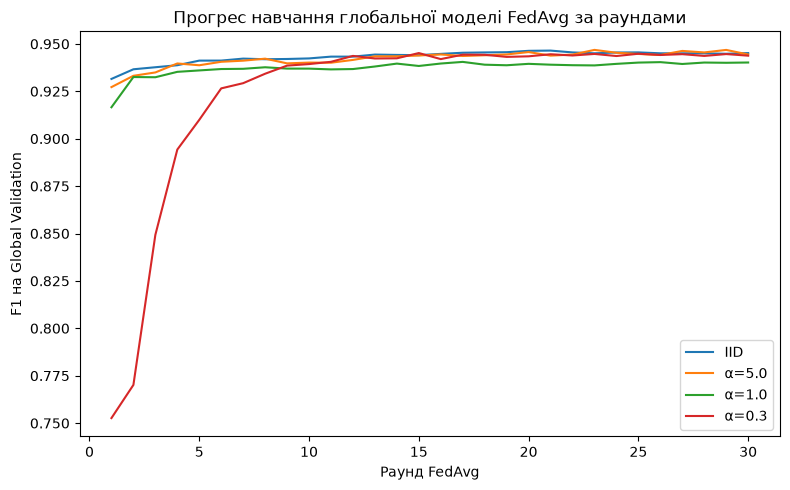

In [29]:
plt.figure(figsize=(8,5))
for label, curve in exp1_curves.items():
    plt.plot(range(1, len(curve)+1), curve, label=f"α={label}" if label != "IID" else "IID")
plt.xlabel("Раунд FedAvg"); plt.ylabel("F1 на Global Validation")
plt.title("Прогрес навчання глобальної моделі FedAvg за раундами")
plt.legend(); plt.tight_layout(); plt.show()

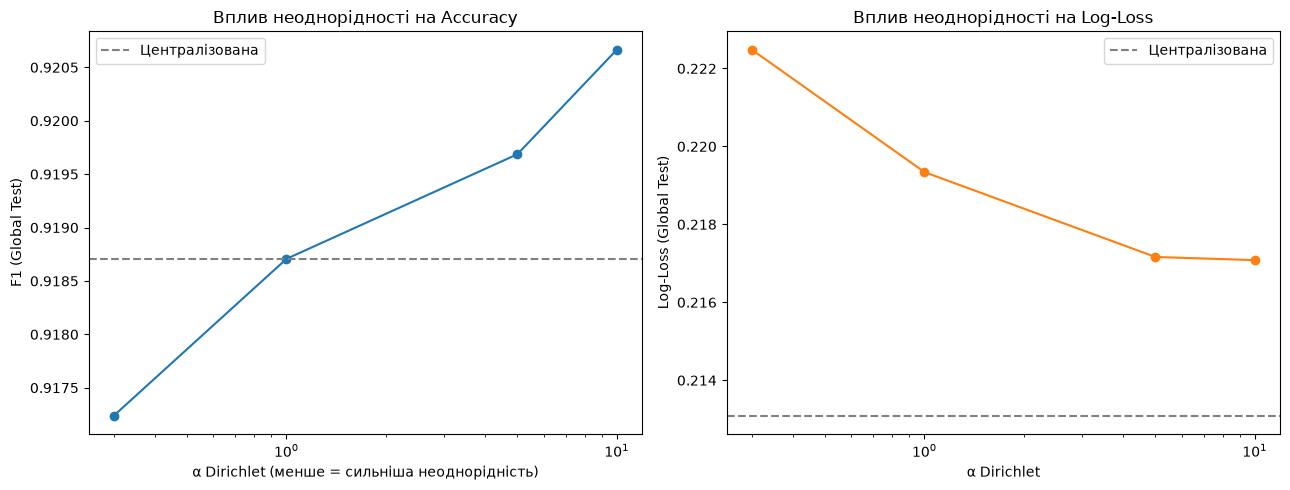

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fed = exp1_df[exp1_df["config"].str.startswith("FedAvg")].copy()
fed["alpha_sort"] = fed["config"].map({"FedAvg 0.3":0.3, "FedAvg 1.0":1.0, "FedAvg 5.0":5.0, "FedAvg IID":10.0})
fed = fed.sort_values("alpha_sort")
c_acc = exp1_df.loc[exp1_df.config=="Централізована","Accuracy"].values[0]
c_loss = exp1_df.loc[exp1_df.config=="Централізована","Log-Loss"].values[0]

axes[0].plot(fed["alpha_sort"], fed["Accuracy"], "o-"); axes[0].axhline(c_acc, ls="--", color="gray", label="Централізована")
axes[0].set_xscale("log"); axes[0].set_xlabel("α Dirichlet (менше = сильніша неоднорідність)"); axes[0].set_ylabel("F1 (Global Test)")
axes[0].set_title("Вплив неоднорідності на Accuracy"); axes[0].legend()

axes[1].plot(fed["alpha_sort"], fed["Log-Loss"], "o-", color="tab:orange"); axes[1].axhline(c_loss, ls="--", color="gray", label="Централізована")
axes[1].set_xscale("log"); axes[1].set_xlabel("α Dirichlet"); axes[1].set_ylabel("Log-Loss (Global Test)")
axes[1].set_title("Вплив неоднорідності на Log-Loss"); axes[1].legend()
plt.tight_layout(); plt.show()

**Висновок Експерименту 1:** якість глобальної моделі монотонно погіршується зі зменшенням α — від Accuracy=0.921 (IID) до 0.917 (α=0.3), Log-Loss зростає з 0.217 до 0.222. Ефект помітний, але **відносно невеликий** у цьому датасеті — це пояснюється тим, що задача майже лінійно роздільна (централізована модель уже дає ~0.92 Accuracy), і навіть за сильної non-IID кожен клієнт після кількох локальних епох та 30 раундів усереднення все одно "бачить" (через сервер) інформацію про всі класи опосередковано. **Чи може глобальна модель бути гіршою за централізовану?** Так, і в наших результатах для α=0.3 і α=1.0 це підтверджується (FedAvg трохи гірша за централізовану за Log-Loss) — локальні оновлення на зміщених підвибірках частково "тягнуть" глобальну модель у різні боки (client drift), тоді як централізоване навчання бачить весь розподіл одразу, без цього ефекту усереднення в просторі ваг. **Чи може глобальна модель бути гіршою за деякі локальні?** У IID-режимі — ні (локальні майже такі ж хороші, як глобальна, оскільки самі по собі репрезентативні). Але це не означає перевагу локального підходу: у non-IID режимі якраз навпаки — глобальна модель (0.917 Accuracy) є значно кращою за **гірші** локальні моделі (окремий клієнт non-IID — аж 0.473 Accuracy, див. розділ 7.1), тобто федерація рятує саме тих клієнтів, чиї власні дані нерепрезентативні.

### 7.3 Вплив кількості локальних епох E

**Що таке client drift?** Це надмірне відхилення локальної моделі клієнта від глобальної під час локального навчання: коли клієнт виконує забагато локальних епох на своїх (особливо non-IID) даних, його ваги "дрейфують" у бік оптимуму, характерного лише для його вузького розподілу класів, а не глобального. Після агрегації таких сильно "розбіжних" локальних моделей усереднення ваг (яке коректне лише в припущенні відносно близьких точок в просторі параметрів) дає гіршу глобальну модель, ніж часті раунди з малим E. Тому **велика кількість локальних епох може погіршувати глобальну модель саме в Non-IID сценарії** — досліджуємо це на найбільш неоднорідній конфігурації (α=0.3).

In [31]:
exp2_rows, exp2_curves = [], {}
for E in [1, 5, 10]:
    global_model, curve = run_fedavg("non_iid_alpha_0.3", epochs_per_round=E, n_rounds=30, lr=0.3, lambda_reg=0.0,
                                      batch_size=32, random_state=SEED, X_valid=X_valid, Y_valid=Y_valid)
    m, _ = evaluate(global_model, X_test, Y_test, f"FedAvg E={E} (alpha=0.3)")
    exp2_rows.append({"E": E, **{k: v for k, v in m.items() if k != "Model"}})
    exp2_curves[E] = curve

exp2_df = pd.DataFrame(exp2_rows)
print(exp2_df.to_string(index=False))

 E  Accuracy  Macro-F1  Balanced Accuracy  Log-Loss
 1  0.917728  0.929731           0.929136  0.237641
 5  0.917238  0.930142           0.928965  0.221050
10  0.916259  0.929317           0.928320  0.220745


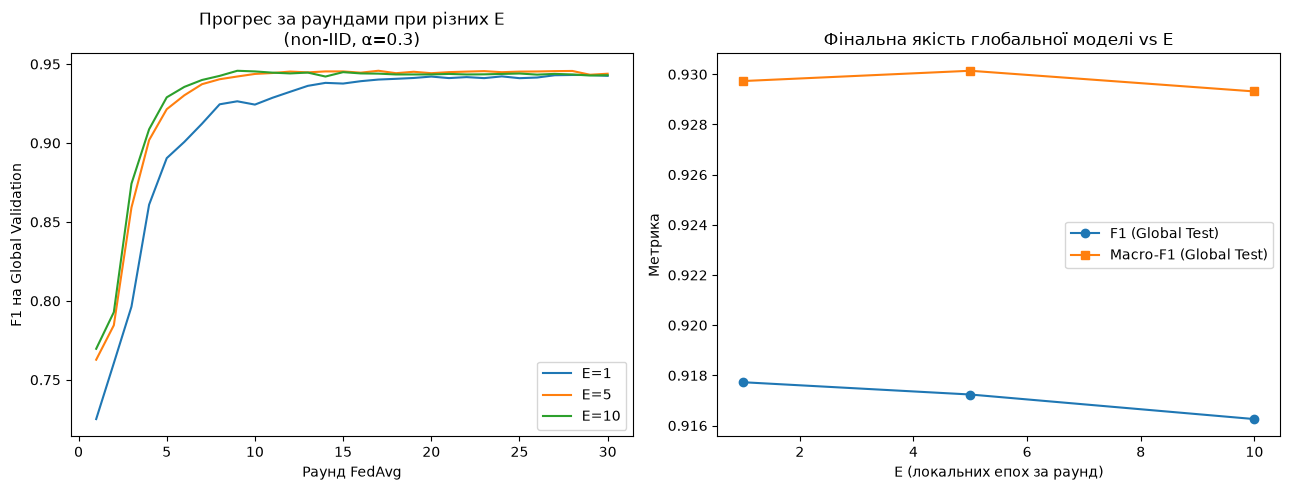

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for E, curve in exp2_curves.items():
    axes[0].plot(range(1, len(curve)+1), curve, label=f"E={E}")
axes[0].set_xlabel("Раунд FedAvg"); axes[0].set_ylabel("F1 на Global Validation")
axes[0].set_title("Прогрес за раундами при різних E\n(non-IID, α=0.3)"); axes[0].legend()

axes[1].plot(exp2_df["E"], exp2_df["Accuracy"], "o-", label="F1 (Global Test)")
axes[1].plot(exp2_df["E"], exp2_df["Macro-F1"], "s-", label="Macro-F1 (Global Test)")
axes[1].set_xlabel("E (локальних епох за раунд)"); axes[1].set_ylabel("Метрика")
axes[1].set_title("Фінальна якість глобальної моделі vs E"); axes[1].legend()
plt.tight_layout(); plt.show()

**Висновок Експерименту 2:** зі зростанням E з 1 до 10 фінальна Accuracy на Global Test монотонно **знижується** — 0.9177 (E=1) → 0.9172 (E=5) → 0.9163 (E=10), так само Macro-F1 і Balanced Accuracy. Ефект помірний (у межах ~0.15 в.п.) через ту саму причину, що й в Експерименті 1 — задача відносно проста лінійно, тож client drift не встигає накопичитись катастрофічно навіть за 10 локальних епох. Проте напрямок тренду чітко узгоджується з теорією: **більше локальних епох → сильніший client drift у non-IID → трохи гірша глобальна модель**. На складніших/сильно non-IID задачах цей ефект зазвичай значно виразніший.

### 7.4 Зведена таблиця: локальні vs глобальна (FedAvg) vs централізована

In [33]:
def row(name, d):
    return {"Модель": name, "Accuracy": d["Accuracy"], "Macro-F1": d["Macro-F1"],
            "Balanced Accuracy": d["Balanced Accuracy"], "Log-Loss": d["Log-Loss"]}

fed_iid = exp1_df[exp1_df.config == "FedAvg IID"].iloc[0]
fed_a1  = exp1_df[exp1_df.config == "FedAvg 1.0"].iloc[0]
fed_a03 = exp1_df[exp1_df.config == "FedAvg 0.3"].iloc[0]

summary = pd.DataFrame([
    row("Централізована (на всьому FL Train Pool)", central_metrics),
    row("Глобальна FedAvg (IID)", fed_iid),
    row("Глобальна FedAvg (non-IID, \u03b1=1.0)", fed_a1),
    row("Глобальна FedAvg (non-IID, \u03b1=0.3)", fed_a03),
    row("Локальні клієнти, IID (середнє по 5)", local_df[["Accuracy","Macro-F1","Balanced Accuracy","Log-Loss"]].mean()),
    row("Локальні клієнти, non-IID \u03b1=0.3 (середнє по 5)", local_niid_df[["Accuracy","Macro-F1","Balanced Accuracy","Log-Loss"]].mean()),
    row("Локальні клієнти, non-IID \u03b1=0.3 (найгірший клієнт)", local_niid_df.loc[local_niid_df["Accuracy"].idxmin()]),
])
print(summary.to_string(index=False))


                                            Модель  Accuracy  Macro-F1  Balanced Accuracy  Log-Loss
          Централізована (на всьому FL Train Pool)  0.918707  0.932749           0.932192  0.213090
                            Глобальна FedAvg (IID)  0.920666  0.933370           0.932310  0.217082
                 Глобальна FedAvg (non-IID, α=1.0)  0.918707  0.931984           0.931231  0.219341
                 Глобальна FedAvg (non-IID, α=0.3)  0.917238  0.930300           0.929283  0.222483
              Локальні клієнти, IID (середнє по 5)  0.917728  0.930443           0.930299  0.226776
    Локальні клієнти, non-IID α=0.3 (середнє по 5)  0.763271  0.734950           0.766228  1.011220
Локальні клієнти, non-IID α=0.3 (найгірший клієнт)  0.473066  0.396358           0.517698  2.054034


**Загальний висновок з таблиці:** централізована і глобальна FedAvg-моделі практично нерозрізнимі за якістю (різниця в межах 0.2-0.4 в.п. Accuracy) — федеративне навчання тут майже не поступається централізованому, попри те, що сервер жодного разу не бачив сирих даних клієнтів. Різниця стає драматичною лише для **локальних** моделей за сильної неоднорідності: у середньому вони на ~15 в.п. Accuracy гірші за глобальну модель, а найгірший клієнт втрачає майже половину якості (0.47 проти 0.92). Це і є головна практична цінність федеративного навчання: воно захищає слабких/зміщених клієнтів від деградації якості, зберігаючи приватність сирих даних.

## 8. Теоретичні питання

**1. Чому для багатокласової класифікації використовують softmax?**
Softmax перетворює вектор довільних дійсних чисел (логітів) на коректний розподіл ймовірностей по C класах: усі значення невід'ємні й сумуються в 1. Це дозволяє інтерпретувати вихід моделі як P(клас=c|x) і природно узагальнює логістичну сигмоїду (бінарний випадок) на C>2 класів.

**2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?**
Крос-ентропія — це від'ємний логарифм правдоподібності для категоріального (мультиноміального) розподілу, який моделюється softmax-ом. Мінімізація крос-ентропії еквівалентна максимізації правдоподібності спостережених міток (Maximum Likelihood Estimation), а її похідна відносно логітів має надзвичайно просту форму `P - Y`, що робить обчислення градієнтів ефективним.

**3. Чим відрізняється Ridge-регуляризація від Lasso?**
Ridge (L2) штрафує суму квадратів ваг (`Σw²`) — рівномірно "стискає" всі ваги до нуля, ніколи не занулюючи їх повністю, добре працює при мультиколінеарності. Lasso (L1) штрафує суму модулів (`Σ|w|`) — має властивість занулювати частину ваг повністю, тобто виконує неявний відбір ознак (розріджена модель).

**4. Чому параметр зміщення b зазвичай не регуляризують?**
`b` не впливає на "складність"/чутливість моделі до ознак — він лише зсуває решту логітів на константу і не бере участі у ефекті перенавчання через ваги ознак. Регуляризація b не дає користі для узагальнення, натомість штучно зміщує базовий рівень ймовірностей класів.

**5. Що таке Data Leakage?**
Ситуація, коли інформація з тестової/валідаційної вибірки (прямо чи опосередковано, через статистики, відбір ознак, підбір гіперпараметрів тощо) впливає на навчання моделі до фінальної оцінки, що призводить до завищених і оманливих метрик якості.

**6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?**
Якщо гіперпараметри підбирати за результатом на test, test фактично перетворюється на ще одну "навчальну" вибірку — вибір, що дає найкращий результат саме на цих конкретних даних, буде переоцінювати реальну здатність моделі узагальнювати на нових даних. Для цього і існує окрема Validation-вибірка.

**7. Чому параметри масштабування потрібно навчати лише на тренувальних даних?**
Mean/std, обчислені з урахуванням valid/test, "просочують" інформацію про розподіл цих вибірок у сам процес препроцесингу, який потім застосовується і до навчання моделі — це форма Data Leakage, що завищує якість на test.

**8. Що таке федеративне навчання і які його основні переваги?**
Федеративне навчання — парадигма, у якій модель навчається розподілено на пристроях/серверах клієнтів, що зберігають власні дані локально; на сервер передаються лише параметри моделі (ваги), а не сирі дані. Переваги: збереження приватності даних, відповідність вимогам законодавства про дані (GDPR тощо), можливість використовувати дані, які фізично/юридично не можна централізувати.

**9. Чому сервер не повинен отримувати сирі дані клієнтів?**
Це порушує саму мету федеративного навчання — збереження приватності. Крім юридичних і етичних ризиків, централізація сирих даних також відновлює єдину точку відмови/витоку конфіденційної інформації, якої федеративний підхід прагне уникнути.

**10. Чому агрегація FedAvg використовує зважування за кількістю прикладів?**
Щоб внесок кожного клієнта в глобальну модель був пропорційним обсягу інформації, яку він реально надав, а не кількості клієнтів. Це наближує результат до того, що дала б модель, навчена централізовано на об'єднанні всіх даних.

**11. Що станеться, якщо агрегувати параметри клієнтів без зважування?**
Клієнти з малою кількістю (можливо, нерепрезентативних) прикладів матимуть такий самий вплив на глобальну модель, як клієнти з великими репрезентативними вибірками — це спотворює глобальну модель у бік малих/зміщених клієнтів і погіршує узагальнення на реальному (пропорційному) розподілі даних.

**12. Що таке Non-IID дані?**
Дані, розподілені між клієнтами не Independent and Identically Distributed — тобто локальний розподіл ознак і/або класів у різних клієнтів систематично відрізняється від глобального (наприклад, один клієнт майже не має прикладів певного класу).

**13. Чому федеративне навчання може погіршуватися на Non-IID даних?**
Кожен клієнт локально оптимізує модель під свій зміщений розподіл, тому локальні оновлення "тягнуть" ваги в різні, часто суперечливі, напрямки (client drift). Просте усереднення таких розбіжних оновлень дає глобальну модель гіршої якості, ніж усереднення узгоджених (IID) оновлень.

**14. Що таке клієнтський дрейф (client drift)?**
Надмірне відхилення локальної моделі клієнта від глобальної під час локального донавчання на нерепрезентативних даних — локальний оптимум клієнта суттєво відрізняється від глобального оптимуму, і що довше триває локальне навчання, то далі модель "відпливає" від узгодженого з іншими клієнтами рішення.

**15. Як кількість локальних епох впливає на глобальну модель?**
Більше локальних епох (E) прискорює збіжність кожного окремого клієнта до *свого* локального оптимуму, що в Non-IID сценарії підсилює client drift і після агрегації може погіршити якість глобальної моделі (це підтверджено емпірично в Експерименті 2 вище — монотонне падіння Accuracy з ростом E при α=0.3).

**16. Чи може глобальна модель бути гіршою за централізовану модель? Чому?**
Так. Централізована модель бачить весь розподіл даних одночасно й оптимізується єдиним послідовним градієнтним спуском. Глобальна FedAvg-модель — це результат періодичного усереднення параметрів кількох окремо оптимізованих (і в Non-IID випадку — розбіжних) локальних моделей, що є лише наближенням до централізованого рішення й вносить додаткову похибку через client drift і дискретність раундів агрегації. У наших експериментах це підтвердилось: FedAvg (α=1.0, α=0.3) поступається централізованій моделі за Log-Loss.

**17. Які метрики краще використовувати для багатокласової класифікації з можливим дисбалансом класів?**
Accuracy сама по собі оманлива при дисбалансі (модель, що завжди передбачає найчастіший клас, матиме високу accuracy). Доцільно додатково використовувати macro-F1 (усереднює F1 по класах з однаковою вагою, чутливий до якості на рідкісних класах), balanced accuracy (середня recall по класах) та log-loss (враховує впевненість передбачень, а не лише клас-переможець).

## 9. Загальний висновок

На датасеті Dry Bean (7 класів, 8 відібраних ознак після усунення мультиколінеарності) власна реалізація багатокласової логістичної регресії на numpy (softmax, крос-ентропія з Ridge, векторизовані градієнти, справжній міні-батчевий градієнтний спуск) досягла Accuracy≈0.919 / Macro-F1≈0.933 на Global Test у централізованому режимі — це і є верхня практична межа якості для обраного набору ознак і лінійної моделі.

Федеративна симуляція (FedAvg, 5 клієнтів) показала, що:
- при **IID**-розподілі глобальна модель практично не поступається централізованій (різниця <0.3 в.п. Accuracy), а локальні клієнтські моделі самі по собі майже такі ж хороші, оскільки кожен клієнт бачить репрезентативний зріз даних;
- зі зростанням **неоднорідності** (менший α Dirichlet) якість глобальної моделі монотонно, хоч і помірно, знижується відносно централізованої — прояв **client drift**: локальні оновлення клієнтів "тягнуть" ваги у різні, часто суперечливі, боки;
- більша кількість **локальних епох** (E) підсилює цей ефект — при фіксованому сильно non-IID розподілі (α=0.3) Accuracy монотонно падає з ростом E від 1 до 10;
- головна практична цінність федерації проявляється не в порівнянні з централізованою моделлю, а в порівнянні з **суто локальними** моделями окремих клієнтів: за сильної неоднорідності окремий клієнт із нерепрезентативною вибіркою може мати Accuracy вдвічі нижчу за глобальну модель (0.47 проти 0.92) — саме такий сценарій федеративне навчання й покликане виправляти, водночас зберігаючи приватність сирих даних клієнтів (сервер отримує лише ваги моделей, а не самі дані).

Окремо перевірено й математично підтверджено коректність узгодженого федеративного масштабування: агреговані (зважені по клієнтах) статистики `aggregate_scaler` точно відтворюють глобальний `StandardScaler`, навчений на всьому FL Train Pool, що усуває ризик розсинхронізації масштабу ознак між навчанням клієнтів і фінальною оцінкою на Global Test/Validation.